# Evaluation Results - All 15 MVTec AD Categories

Full analysis of PatchCore performance across all categories.
Understanding where the model works, where it struggles, and why.

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

with open('../experiments/results/results.json') as f:
    results = json.load(f)

overall      = results['overall']
per_category = results['per_category']

categories = [r['category'] for r in per_category]
aurocs     = [r['auroc']    for r in per_category]
aps        = [r['average_precision'] for r in per_category]

print(f"Overall AUROC: {overall['mean_auroc']} +- {overall['std_auroc']}")
print(f"Overall AP:    {overall['mean_average_precision']} +- {overall['std_average_precision']}")
print(f"Categories:    {overall['n_categories']}")


Overall AUROC: 0.9781 +- 0.0316
Overall AP:    0.9905 +- 0.013
Categories:    15


## AUROC per Category

Sorted from best to worst. Green = above 0.98, orange = 0.95 to 0.98, red = below 0.95.

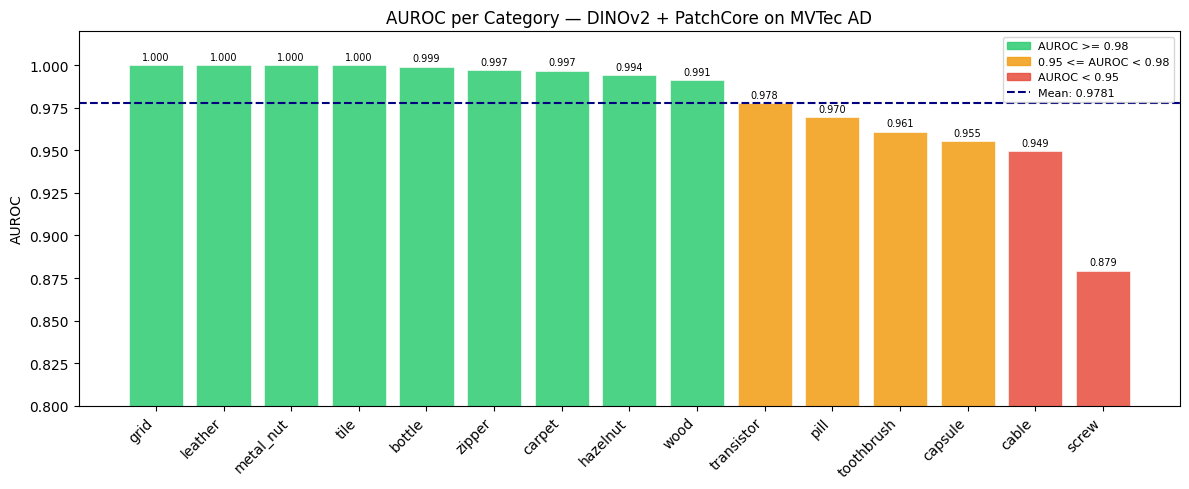

In [10]:
sorted_data = sorted(zip(categories, aurocs, aps), key=lambda x: x[1], reverse=True)
sorted_cats, sorted_aurocs, sorted_aps = zip(*sorted_data)

colors = ['#2ecc71' if a >= 0.98 else '#f39c12' if a >= 0.95 else '#e74c3c'
          for a in sorted_aurocs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sorted_cats, sorted_aurocs, color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)

ax.axhline(overall['mean_auroc'], color='navy', linestyle='--', linewidth=1.5,
           label=f"Mean AUROC: {overall['mean_auroc']}")

for bar, val in zip(bars, sorted_aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_ylim(0.8, 1.02)
ax.set_ylabel('AUROC')
ax.set_title('AUROC per Category — DINOv2 + PatchCore on MVTec AD')
ax.set_xticks(range(len(sorted_cats)))
ax.set_xticklabels(sorted_cats, rotation=45, ha='right')

patches = [
    mpatches.Patch(color='#2ecc71', alpha=0.85, label='AUROC >= 0.98'),
    mpatches.Patch(color='#f39c12', alpha=0.85, label='0.95 <= AUROC < 0.98'),
    mpatches.Patch(color='#e74c3c', alpha=0.85, label='AUROC < 0.95'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               label=f"Mean: {overall['mean_auroc']}"),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig('../experiments/results/auroc_per_category.png', dpi=150)
plt.show()


## AUROC vs Average Precision

Do categories that score well on AUROC also score well on AP?
High correlation means the two metrics agree on which categories are hard.

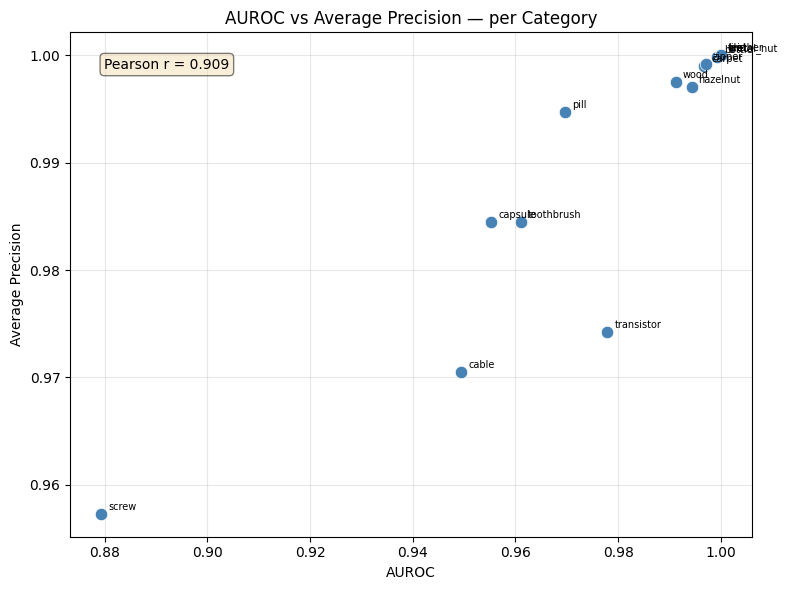

Pearson correlation: 0.9090


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(aurocs, aps, color='steelblue', s=80, edgecolors='white', linewidth=0.5, zorder=3)

for i, cat in enumerate(categories):
    ax.annotate(cat, (aurocs[i], aps[i]),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlabel('AUROC')
ax.set_ylabel('Average Precision')
ax.set_title('AUROC vs Average Precision — per Category')
ax.grid(True, alpha=0.3)

correlation = np.corrcoef(aurocs, aps)[0, 1]
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../experiments/results/auroc_vs_ap.png', dpi=150)
plt.show()
print(f'Pearson correlation: {correlation:.4f}')


## Best and Worst Performing Categories

In [6]:
sorted_by_auroc = sorted(per_category, key=lambda x: x['auroc'], reverse=True)

print("Top 5:")
print(f"{'Category':<15} {'AUROC':<10} {'AP':<10} {'Total'}")
print('-' * 42)
for r in sorted_by_auroc[:5]:
    print(f"{r['category']:<15} {r['auroc']:<10} {r['average_precision']:<10} {r['n_total']}")

print("\nBottom 5:")
print(f"{'Category':<15} {'AUROC':<10} {'AP':<10} {'Total'}")
print('-' * 42)
for r in sorted_by_auroc[-5:]:
    print(f"{r['category']:<15} {r['auroc']:<10} {r['average_precision']:<10} {r['n_total']}")


Top 5:
Category        AUROC      AP         Total
------------------------------------------
grid            1.0        1.0        78
leather         1.0        1.0        124
metal_nut       1.0        1.0        115
tile            1.0        1.0        117
bottle          0.9992     0.9998     83

Bottom 5:
Category        AUROC      AP         Total
------------------------------------------
pill            0.9697     0.9947     167
toothbrush      0.9611     0.9845     42
capsule         0.9553     0.9845     132
cable           0.9494     0.9705     150
screw           0.8793     0.9573     160


## Failure Analysis - Why Does Screw Score Lowest?

Screw achieves AUROC 0.879 - the lowest of all 15 categories.
Understanding why is more valuable than the number itself.

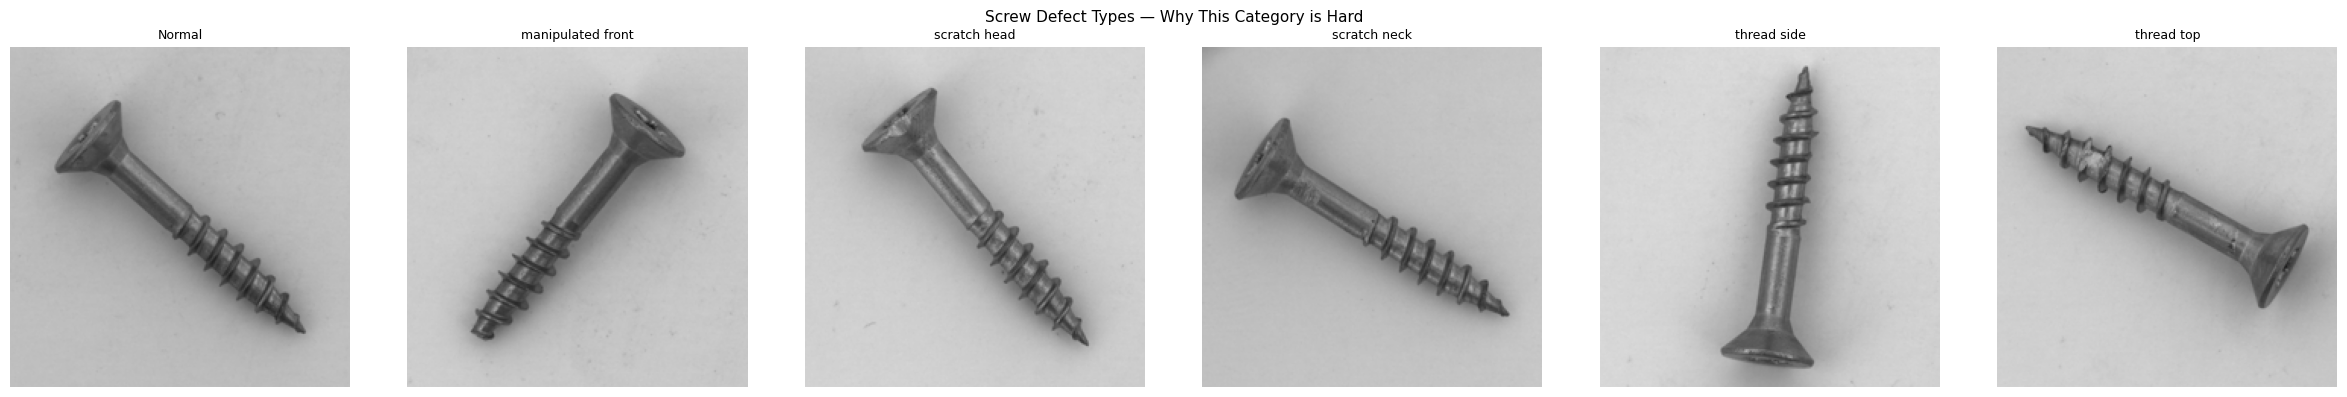

Why screw is the hardest category:
1. Screws appear at different orientations — the normal feature distribution is wide
2. Subtle defects like scratches and manipulated threads overlap with pose variance
3. 160 test images across many fine-grained defect types — most demanding test set


In [7]:
import os
from PIL import Image

DATA_ROOT = Path('../data/mvtec')
screw_test   = DATA_ROOT / 'screw' / 'test'
defect_types = sorted([d for d in os.listdir(screw_test) if d != 'good'])

fig, axes = plt.subplots(1, len(defect_types) + 1, figsize=(4 * (len(defect_types) + 1), 4))

normal_imgs = list((screw_test / 'good').glob('*.png'))
img = Image.open(normal_imgs[0]).convert('RGB').resize((224, 224))
axes[0].imshow(img)
axes[0].set_title('Normal', fontsize=9)
axes[0].axis('off')

for i, defect in enumerate(defect_types):
    imgs = list((screw_test / defect).glob('*.png'))
    if imgs:
        img = Image.open(imgs[0]).convert('RGB').resize((224, 224))
        axes[i+1].imshow(img)
        axes[i+1].set_title(defect.replace('_', ' '), fontsize=9)
        axes[i+1].axis('off')

plt.suptitle('Screw Defect Types — Why This Category is Hard', fontsize=11)
plt.tight_layout()
plt.savefig('../experiments/results/screw_defect_analysis.png', dpi=150)
plt.show()

print("Why screw is the hardest category:")
print("1. Screws appear at different orientations — the normal feature distribution is wide")
print("2. Subtle defects like scratches and manipulated threads overlap with pose variance")
print("3. 160 test images across many fine-grained defect types — most demanding test set")


## Perfect Categories 

In [8]:
perfect = [r for r in per_category if r['auroc'] == 1.0]
print(f"Categories with perfect AUROC (1.0): {[r['category'] for r in perfect]}")
print()
print("Grid       — highly regular repeating pattern. Any deviation is immediately anomalous.")
print("Leather    — consistent texture, no pose variation. Normal features cluster very tightly.")
print("Metal nut  — rigid object, fixed orientation, distinctive defects.")
print("Tile       — flat uniform texture. Cracks and colour changes break regularity strongly.")


Categories with perfect AUROC (1.0): ['grid', 'leather', 'metal_nut', 'tile']

Grid       — highly regular repeating pattern. Any deviation is immediately anomalous.
Leather    — consistent texture, no pose variation. Normal features cluster very tightly.
Metal nut  — rigid object, fixed orientation, distinctive defects.
Tile       — flat uniform texture. Cracks and colour changes break regularity strongly.


## Full Results Table

In [9]:
print(f"{'Category':<15} {'AUROC':<10} {'AP':<10} {'Normal':<8} {'Anomaly':<10} {'Total'}")
print('-' * 60)
for r in sorted(per_category, key=lambda x: x['auroc'], reverse=True):
    print(f"{r['category']:<15} {r['auroc']:<10} {r['average_precision']:<10} "
          f"{r['n_normal']:<8} {r['n_anomaly']:<10} {r['n_total']}")
print('-' * 60)
print(f"{'OVERALL':<15} {overall['mean_auroc']:<10} {overall['mean_average_precision']:<10}")


Category        AUROC      AP         Normal   Anomaly    Total
------------------------------------------------------------
grid            1.0        1.0        21       57         78
leather         1.0        1.0        32       92         124
metal_nut       1.0        1.0        22       93         115
tile            1.0        1.0        33       84         117
bottle          0.9992     0.9998     20       63         83
zipper          0.9971     0.9992     32       119        151
carpet          0.9968     0.999      28       89         117
hazelnut        0.9943     0.997      40       70         110
wood            0.9912     0.9975     19       60         79
transistor      0.9779     0.9742     60       40         100
pill            0.9697     0.9947     26       141        167
toothbrush      0.9611     0.9845     12       30         42
capsule         0.9553     0.9845     23       109        132
cable           0.9494     0.9705     58       92         150
screw      

## Key Takeaways

- 4 categories achieve perfect AUROC of 1.0: grid, leather, metal_nut, tile. Grid has a
  highly regular repeating pattern where any deviation is immediately anomalous. Leather and
  tile are flat textures with no pose variation. Metal nut is a rigid object with distinctive
  defects like bending and flipping.
- Screw is the hardest category at AUROC 0.8793. It has 5 fine-grained defect types, the
  highest test set size at 160 images, and significant pose variation in normal images that
  widens the memory bank distribution.
- The bottom 5 categories (pill, toothbrush, capsule, cable, screw) all share one property:
  either pose variation, subtle fine-grained defects, or both.
- AUROC and AP are strongly correlated at Pearson r = 0.909, meaning both metrics agree on
  which categories are hard. The difficulty ranking is consistent.
- Overall 0.9781 mean AUROC with a frozen DINOv2 backbone and zero defect labels is a strong
  result. The original PatchCore paper reports approximately 0.99 using larger ResNet backbones
  with full coreset on full resolution images. The gap is explained by our 10% coreset ratio
  and 224x224 resolution constraint from laptop GPU memory.